In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. 가상 커패시터 이미지 생성 함수 (Good / Defective)
def create_synthetic_capacitor_dataset(base_dir='synthetic_capacitors', num_samples=100):
    for label in ['Good', 'Defective']:
        path = os.path.join(base_dir, label)
        os.makedirs(path, exist_ok=True)
        for i in range(num_samples):
            # 224x224 단색 배경 (커패시터 바디)
            img = Image.new('RGB', (224, 224), color=(180, 180, 190))
            draw = ImageDraw.Draw(img)

            # 커패시터 윤곽선 (정상적인 형태)
            draw.rectangle([40, 60, 184, 164], fill=(100, 100, 110), outline=(50, 50, 50), width=3)

            # 불량(Defective) 샘플에 크랙(Crack) 및 오염(Contamination) 패턴 추가
            if label == 'Defective':
                # 흰색/검은색 스크래치(Crack) 또는 얼룩
                x1 = np.random.randint(60, 140)
                y1 = np.random.randint(80, 140)
                draw.line([(x1, y1), (x1+30, y1+20)], fill=(30, 30, 30), width=4)
                draw.ellipse([x1, y1, x1+15, y1+15], fill=(50, 20, 20))

            img.save(os.path.join(path, f"{label}_{i:03d}.png"))

create_synthetic_capacitor_dataset()
print("▶ 가상 커패시터 데이터셋 생성 완료")

▶ 가상 커패시터 데이터셋 생성 완료


In [5]:
# 30p: 데이터 증강 - 회전, 뒤집기, 밝기 조정 적용
train_transform = transforms.Compose([
    transforms.RandomRotation(degrees=15),                 # 무작위 회전
    transforms.RandomHorizontalFlip(p=0.5),                # 수평 뒤집기
    transforms.RandomVerticalFlip(p=0.5),                  # 수직 뒤집기
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # 밝기 및 대비 조정
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class CapacitorDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = ['Good', 'Defective']
        self.image_paths = []
        self.labels = []

        for idx, cls in enumerate(self.classes):
            cls_dir = os.path.join(root_dir, cls)
            for file in os.listdir(cls_dir):
                self.image_paths.append(os.path.join(cls_dir, file))
                self.labels.append(idx)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

dataset = CapacitorDataset('synthetic_capacitors', transform=train_transform)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 30p: ResNet-18 Backbone + Fine-tuning
model = models.resnet18(pretrained=True)
# 1. 모델의 전체 구조 출력 (맨 마지막 줄 확인)
print(model)

!pip install torchinfo
from torchinfo import summary

# 224x224 RGB 이미지 1장(배치 크기=1)이 들어간다고 가정하고 요약표 출력
summary(
    model,
    input_size=(1, 3, 224, 224),
    col_names=["input_size", "output_size", "num_params"],
    depth=3 # 레이어 세부 구조를 몇 단계까지 들어갈지 설정
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\AI-00/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


SSLError: [ASN1: NOT_ENOUGH_DATA] not enough data (_ssl.c:4040)

In [ ]:
# 최종 Output Layer 수정 (2개 클래스: Good vs Defective)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)
model = model.to(device)

# 손실함수 및 옵티마이저 (Fine-tuning을 위해 학습률을 낮게 설정)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

Epoch [1/5] Loss: 0.2346
Epoch [2/5] Loss: 0.0127
Epoch [3/5] Loss: 0.0045
Epoch [4/5] Loss: 0.0005
Epoch [5/5] Loss: 0.0012

▶ [분류 성능 평가 보고서]
                precision    recall  f1-score   support

     Good (정상)       1.00      1.00      1.00        23
Defective (불량)       1.00      1.00      1.00        17

      accuracy                           1.00        40
     macro avg       1.00      1.00      1.00        40
  weighted avg       1.00      1.00      1.00        40



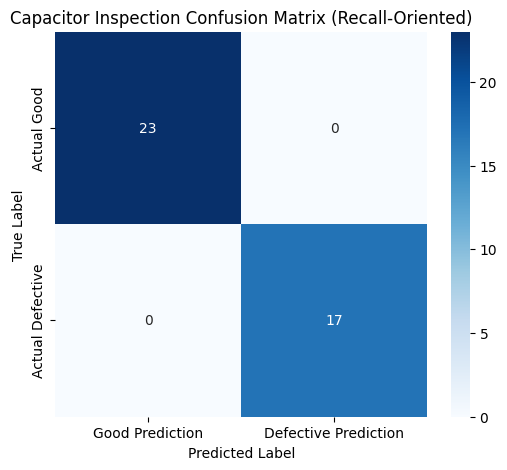

In [ ]:
# 1. 간단한 학습 루프 (5 Epoch 실습용)
model.train()
for epoch in range(5):
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch [{epoch+1}/5] Loss: {running_loss/len(train_loader):.4f}")

# 2. 모델 평가 및 Confusion Matrix / F1-Score 계산
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# 30p 지표 산출: Accuracy, Precision, Recall, F1-score
print("\n▶ [분류 성능 평가 보고서]")
print(classification_report(all_labels, all_preds, target_names=['Good (정상)', 'Defective (불량)']))

# Confusion Matrix 시각화
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Good Prediction', 'Defective Prediction'],
            yticklabels=['Actual Good', 'Actual Defective'])
plt.title("Capacitor Inspection Confusion Matrix (Recall-Oriented)")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

val_dataset에 불량 샘플이 없어 전체 dataset에서 불러옵니다.


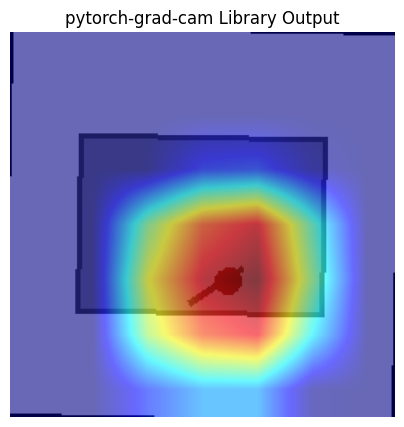

In [ ]:
!pip install grad-cam
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 1. 라이브러리 임포트
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# 2. 검사할 타겟 레이어 지정 (리스트 형태로 넣음)
target_layers = [model.layer4[-1].conv2]

# 3. CAM 객체 생성 (Hooks 등록, 기울기 계산 등 복잡한 내부 로직을 알아서 처리)
cam = GradCAM(model=model, target_layers=target_layers)

# 4. 분석할 클래스 지정 (Defective = 클래스 1)
targets = [ClassifierOutputTarget(1)]

# 5. 히트맵 생성 (결과는 0~1 사이의 224x224 넘파이 배열로 알아서 출력됨!)
# (input_batch: [1, 3, 224, 224] 형태의 텐서)
defective_indices = [i for i, lbl in enumerate(val_dataset) if lbl == 1]

if len(defective_indices) > 0:
    # 1) 검증 데이터셋(val_dataset) 안에 불량 샘플이 있으면 첫 번째 불량 선택
    sample_idx = defective_indices[0]
    input_tensor, label = val_dataset[sample_idx]
    print(f"val_dataset에서 불량 샘플(인덱스 {sample_idx})을 성공적으로 선택했습니다.")
else:
    # 2) 만약 random_split으로 인해 val_dataset에 불량이 하나도 없다면, 전체 dataset에서 직접 가져오기 (예외 처리)
    print("val_dataset에 불량 샘플이 없어 전체 dataset에서 불러옵니다.")
    all_defective_indices = [i for i, lbl in enumerate(dataset.labels) if lbl == 1]
    input_tensor, label = dataset[all_defective_indices[0]]
input_batch = input_tensor.unsqueeze(0).to(device)

grayscale_cam = cam(input_tensor=input_batch, targets=targets)[0, :]

# 원본 이미지 복원 (정규화 해제)
img_np = input_tensor.permute(1, 2, 0).numpy()
img_np = img_np * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
img_np = np.clip(img_np, 0, 1)

# 6. [핵심] 원본 이미지와 오버레이 (우리가 직접 짰던 0.55*img + 0.45*cam 연산을 한 방에!)
# * 주의: show_cam_on_image의 첫 번째 인자는 0.0~1.0 float 형태의 RGB 이미지여야 합니다.
overlay_img = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

# 7. 시각화 출력
plt.figure(figsize=(5, 5))
plt.imshow(overlay_img)
plt.title("pytorch-grad-cam Library Output")
plt.axis('off')
plt.show()